In [61]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

from torchinfo import summary

from going_modular import data_setup, engine


In [62]:
# data_setup.create_dataloader()
# engine.train()

In [63]:
# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [64]:
from pathlib import Path

data_dir = Path('data/pizza_sushi_steak/')

train_dir = data_dir / 'train'
test_dir =  data_dir / 'test'

train_dir, test_dir

(WindowsPath('data/pizza_sushi_steak/train'),
 WindowsPath('data/pizza_sushi_steak/test'))

## 1. Create Dataset and DataLoaders

In [65]:
from going_modular import data_setup

### 1.1 Creating transform (manual creation)

In [66]:
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])


In [67]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=manual_transforms,
                                                                              batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1cfcf0a3820>,
 ['pizza', 'steak', 'sushi'])

### 1.2 Creating transform (auto creation)

In [68]:
# Get a set of pretrained model weights
weights = torchvision.models.ResNet101_Weights.DEFAULT
weights

ResNet101_Weights.IMAGENET1K_V2

In [69]:
# Get the transorms
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [70]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=auto_transforms,
                                                                              batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1cfcf1cb9b0>,
 ['pizza', 'steak', 'sushi'])

## 2. Getting a pretrained model

In [87]:
model = torchvision.models.resnet101(weights).to(device)
model

c:\Users\mahdi\Desktop\programming\homework\env\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [88]:
for name, module in model.named_children():
    print(name, module.__class__.__name__)

conv1 Conv2d
bn1 BatchNorm2d
relu ReLU
maxpool MaxPool2d
layer1 Sequential
layer2 Sequential
layer3 Sequential
layer4 Sequential
avgpool AdaptiveAvgPool2d
fc Linear


In [89]:
model.layer1

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, ke

In [90]:
model.layer2

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(

In [91]:
model.layer3

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(256, 1024, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(512, 1024, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Co

In [92]:
model.layer4

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): 

In [93]:
model.avgpool

AdaptiveAvgPool2d(output_size=(1, 1))

In [94]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

## 3. Getting a summary of model

In [95]:
from torchinfo import summary

summary(model=model,
        input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'])
        

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [1, 3, 224, 224]          [1, 1000]                 --                        True
├─Conv2d (conv1)                         [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
├─ReLU (relu)                            [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d (maxpool)                    [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential (layer1)                    [1, 64, 56, 56]           [1, 256, 56, 56]          --                        True
│    └─Bottleneck (0)                    [1, 64, 56, 56]           [1, 256, 56, 56]          --                        True
│    │ 

### 3.1 Freezing the base model 

In [96]:
# Freeze all of the base layers in Resnet101
for param in model.parameters():
    # When requires_grad is False, PyTorch does not compute or store gradients for that parameter.
    param.requires_grad = False
    

In [97]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [98]:
# Update the Fc layer of the model
model.fc = nn.Linear(in_features=2048, out_features=len(class_names), bias=True).to(device)

In [99]:
model.fc

Linear(in_features=2048, out_features=3, bias=True)

In [100]:
summary(
    model=model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    row_settings=["var_names"],
)

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
ResNet (ResNet)                          [1, 3, 224, 224]          [1, 3]                    --                        Partial
├─Conv2d (conv1)                         [1, 3, 224, 224]          [1, 64, 112, 112]         (9,408)                   False
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]         [1, 64, 112, 112]         (128)                     False
├─ReLU (relu)                            [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d (maxpool)                    [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential (layer1)                    [1, 64, 56, 56]           [1, 256, 56, 56]          --                        False
│    └─Bottleneck (0)                    [1, 64, 56, 56]           [1, 256, 56, 56]          --                        False


## 4. Train model

In [102]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [103]:
# Import train function
from going_modular import engine

# Start the timer
from timeit import default_timer as timer

start_time = timer()

results = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
)

# End the timer 
end_time = timer()
print(f"[INFO] Total training timer: {end_time-start_time:.3f} seconds.")

  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\mahdi\Desktop\programming\homework\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 1/5 [00:20<01:23, 20.93s/it]

Epoch: 0 | Train loss: 1.0600 | Train acc: 0.4336 | Test loss: 0.9576 | Test acc: 0.7453


 40%|████      | 2/5 [00:42<01:03, 21.23s/it]

Epoch: 1 | Train loss: 0.8574 | Train acc: 0.6758 | Test loss: 0.8839 | Test acc: 0.8769


 60%|██████    | 3/5 [01:03<00:42, 21.33s/it]

Epoch: 2 | Train loss: 0.7105 | Train acc: 0.7891 | Test loss: 0.8527 | Test acc: 0.7036


 80%|████████  | 4/5 [01:25<00:21, 21.30s/it]

Epoch: 3 | Train loss: 0.6094 | Train acc: 0.8281 | Test loss: 0.6611 | Test acc: 0.8561


100%|██████████| 5/5 [01:47<00:00, 21.45s/it]

Epoch: 4 | Train loss: 0.5039 | Train acc: 0.9375 | Test loss: 0.6956 | Test acc: 0.8456
[INFO] Total training timer: 107.281 seconds.


In [104]:
results

{'train_loss': [1.060008130967617,
  0.8573926612734795,
  0.7105349749326706,
  0.6094299294054508,
  0.5038653835654259],
 'train_acc': [0.43359375, 0.67578125, 0.7890625, 0.828125, 0.9375],
 'test_loss': [0.9576496283213297,
  0.8838595350583395,
  0.8526848753293356,
  0.6611293355623881,
  0.6956492265065511],
 'test_acc': [0.7452651515151515,
  0.8768939393939394,
  0.7035984848484849,
  0.8560606060606061,
  0.8456439393939394]}

## 5. Evaluate model by plotting loss curves

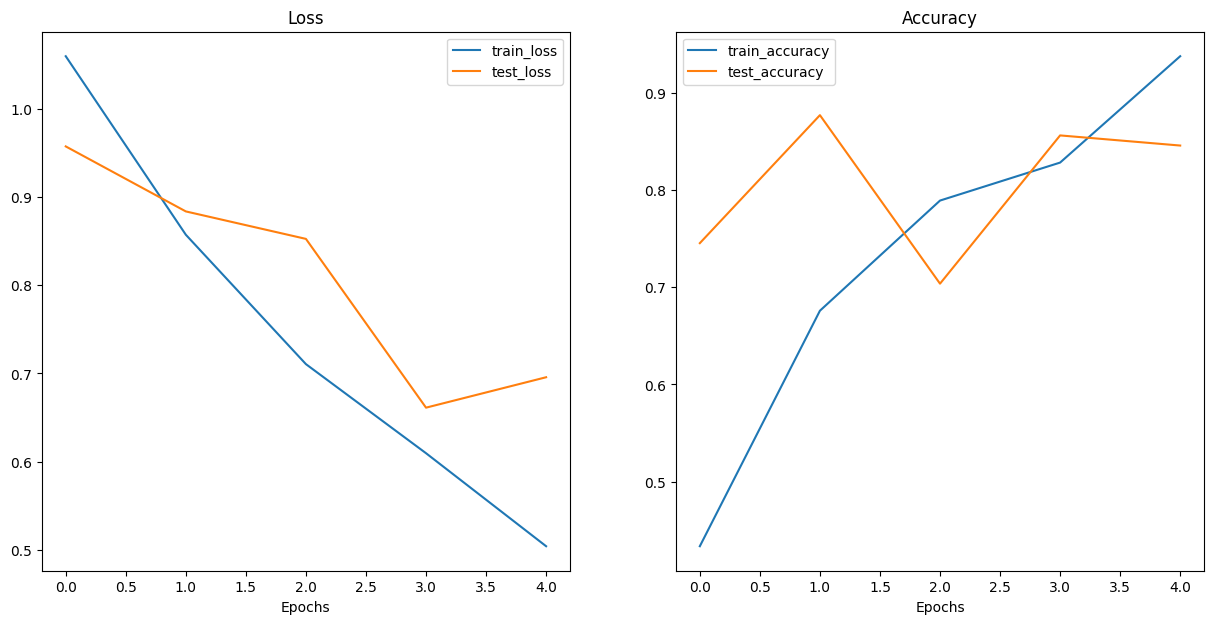

In [105]:
from helper_functions import plot_loss_curves

plot_loss_curves(results)

## 6. Make predictions from the test set

In [112]:
from torchvision.io import read_image
from torchvision import transforms


def pred_plot_image(
                    model: torch.nn.Module,
                    image_path: str,
                    class_names: list[str],
                    image_size: tuple[int, int] = (224, 224),
                    transform: torchvision.transforms = None,
                    device: torch.device = device):

    img = read_image(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])

    model.to(device)
    
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(0)

        target_image_pred = model(transformed_image.to(device))
    
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    target_iamge_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img.permute(1, 2 ,0))
    plt.title(f"Pred: {class_names[target_iamge_pred_label]} | probs: {target_image_pred_probs.max():.3f}")
    plt.axis("off");

In [113]:
test_dir

WindowsPath('data/pizza_sushi_steak/test')

In [118]:
# Get a random list of image paths
import random

test_image_path_list = list(Path(test_dir).glob('*/*.jpg'))
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=3)
test_image_path_sample

[WindowsPath('data/pizza_sushi_steak/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/398345.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/steak/2117351.jpg')]

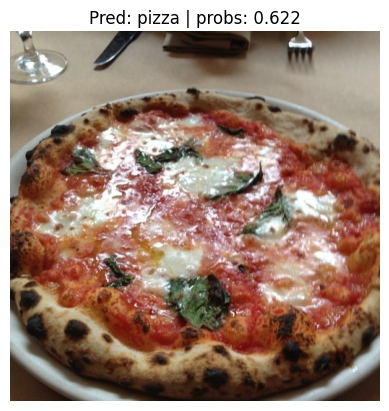

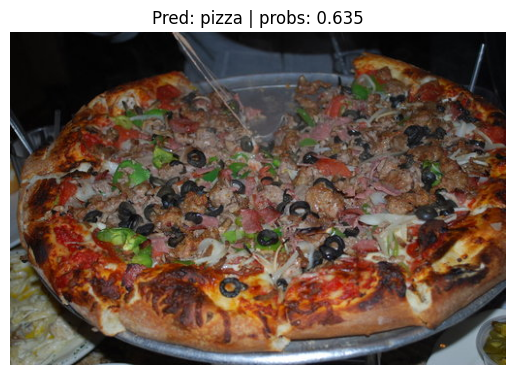

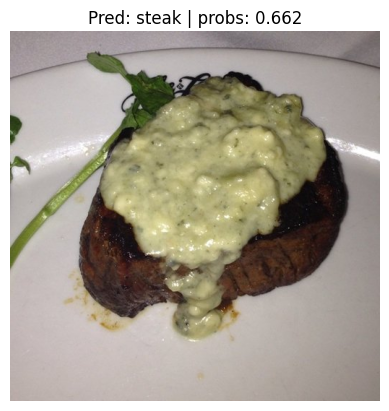

In [119]:
for image_path in test_image_path_sample:
    pred_plot_image(model=model,
                    image_path=image_path,
                    class_names=class_names,
                    image_size=(224, 224))

### 6.1 Making prediction on a custom image

In [121]:
custom_image_path = Path("data/04_dad_pizza.jpeg")
custom_image_path

WindowsPath('data/04_dad_pizza.jpeg')

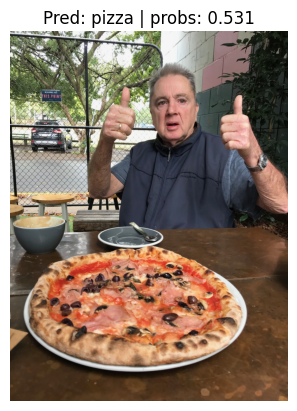

In [122]:
pred_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names,
                    image_size=(224, 224))